
# Lesson 12: Natural Language Processing (Speech Recognition)
## 1. Automatic Speech Recognition (ASR) Overview

Deep learning has played a critical role in the rapid growth of **Automatic Speech Recognition (ASR)**. The task of ASR is to convert spoken language into computer-readable text (transcripts). It maps a continuous audio signal (usually represented as acoustic features) into a sequence of words or sub-words.

### ASR vs TTS vs SLT
*   **Automatic Speech Recognition (ASR)**: Speech-to-Text.
*   **Text-to-Speech (TTS)**: Speech synthesis, mapping text back into an acoustic waveform.
*   **Spoken Language Translation (SLT)**: Transcribing speech into text, and then translating that text into another language.

### Traditional vs Neural ASR
A traditional phonetic-based ASR system (like Hidden Markov Models) uses an equation combining an **Acoustic Model**, **Lexicon Model**, and **Language Model**:
$$ \hat{W} = \arg\max_W P(X|W)P(W) $$
Where $P(X|W)$ is the acoustic model and $P(W)$ is the language model.

In contrast, modern **End-to-End Systems** directly optimize the conditional probability $P(W|X)$ using deep neural networks.



## 2. Preliminaries: Sound Waves & Signal Processing

Sound travels in waves. The two most important properties of a sound wave are:
*   **Amplitude**: The strength of the vibration (volume).
*   **Frequency**: Measured in Hertz (Hz), the number of times the wave changes direction per second (pitch). Humans hear between 20 Hz and 20,000 Hz.

To process audio in deep learning, we must convert the analog wave into a digital format.
1.  **Sampling**: Measuring the amplitude at specific intervals. The *sampling rate* is the number of samples per second (e.g., 16kHz).
2.  **Quantization**: Storing amplitude measurements as discrete integers (e.g., 8-bit or 16-bit).

Below, we simulate generating a sound wave and applying sampling and quantization.


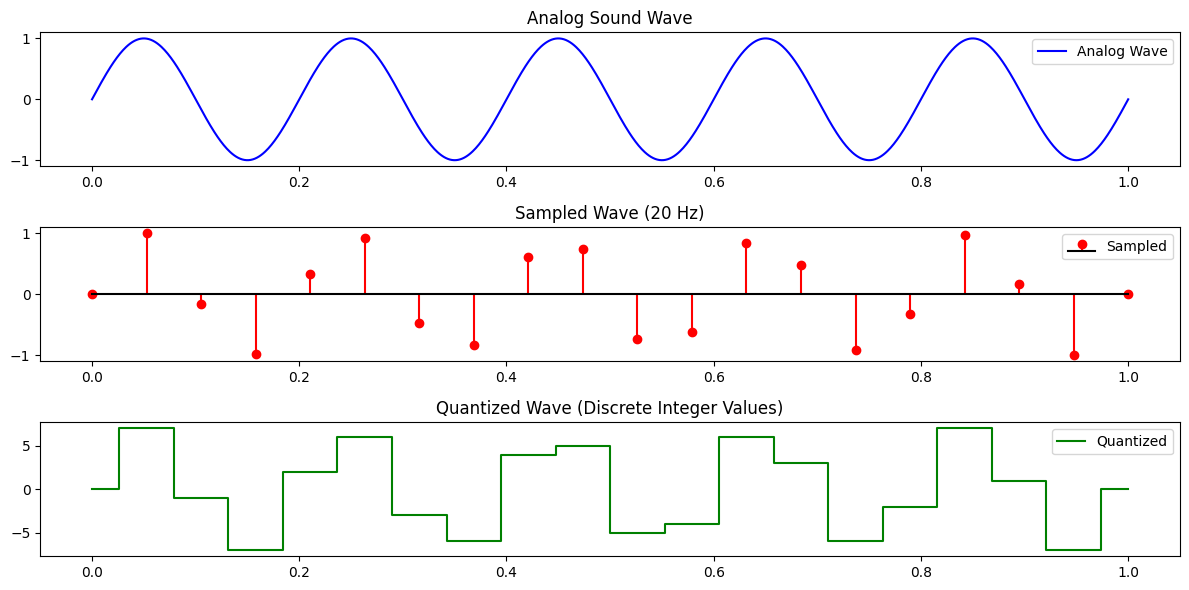

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a continuous analog-like sound wave (Sine Wave)
duration = 1.0       # 1 second
frequency = 5.0      # 5 Hz for visualization purposes
analog_sr = 1000     # High sampling rate to simulate "continuous" analog
t_analog = np.linspace(0, duration, int(analog_sr * duration))
analog_wave = np.sin(2 * np.pi * frequency * t_analog)

# 2. Sampling (lower sampling rate)
sampling_rate = 20   # 20 samples per second
t_sampled = np.linspace(0, duration, int(sampling_rate * duration))
sampled_wave = np.sin(2 * np.pi * frequency * t_sampled)

# 3. Quantization (e.g., 4-bit, values from -8 to 7)
quantization_levels = 16
quantized_wave = np.round(sampled_wave * (quantization_levels / 2 - 1))
quantized_wave = np.clip(quantized_wave, -quantization_levels/2, quantization_levels/2 - 1)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(t_analog, analog_wave, color='blue', label='Analog Wave')
plt.title("Analog Sound Wave")
plt.legend()

plt.subplot(3, 1, 2)
plt.stem(t_sampled, sampled_wave, linefmt='r-', markerfmt='ro', basefmt='k-', label='Sampled')
plt.title(f"Sampled Wave ({sampling_rate} Hz)")
plt.legend()

plt.subplot(3, 1, 3)
plt.step(t_sampled, quantized_wave, color='green', where='mid', label='Quantized')
plt.title("Quantized Wave (Discrete Integer Values)")
plt.legend()

plt.tight_layout()
plt.show()



## 3. Encoder-Decoder Speech Recognizer

The encoder-decoder architecture (often using RNNs, LSTMs, or Transformers) reads spectral features (like Log-Mel Spectrograms) and maps them to letters.

*   **Input Sequence $X$**: $t$ acoustic feature vectors $X = (x_1, x_2, ..., x_t)$.
*   **Output Sequence $Y$**: letters or word-pieces $Y = (y_1, y_2, ..., y_n)$.
*   **Subsampling**: Because $t > n$, we often compress $X$ (e.g., concatenating adjacent frames) before feeding into the encoder.

### Loss Function
Trained with Cross-Entropy Loss over the output sequence:
$$ L = \sum_i -\log P(y_i | y_{<i}, X) $$

### Inference
Inference uses **Greedy Search** or **Beam Search**. Incorporating a Language Model (LM) helps rescore hypothesis beams:
$$ \hat{Y} = \arg\max_Y \log P_{AED}(Y|X) + \lambda \log P_{LM}(Y) $$

Below is a minimal, conceptual PyTorch framework for an Encoder-Decoder.


In [2]:

import torch
import torch.nn as nn

class MinimalSpeechEncoderDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, vocab_size):
        super().__init__()
        # Encoder: processing acoustic features
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Decoder: mapping hidden states to vocabulary probabilities
        # (Note: A true seq2seq would use attention and feed previous predictions)
        self.decoder = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, time_steps, features)
        enc_out, _ = self.encoder(x)
        dec_out, _ = self.decoder(enc_out)
        logits = self.fc(dec_out)
        return logits

# Dummy test
batch_size, time_steps, features = 2, 50, 40  # 40-dim log-mel features
vocab_size = 28 # 26 letters + space + blank

model = MinimalSpeechEncoderDecoder(features, 128, vocab_size)
dummy_audio = torch.randn(batch_size, time_steps, features)

output_logits = model(dummy_audio)
print("Output shape (Batch, Time, Vocab):", output_logits.shape)


Output shape (Batch, Time, Vocab): torch.Size([2, 50, 28])



## 4. Connectionist Temporal Classification (CTC)

An alternative to Encoder-Decoder is **CTC**, which overcomes the challenge of mapping a long sequence $X$ to a shorter transcript $Y$ without knowing exact alignments.

CTC adds a special **blank token** ($\epsilon$) to the alphabet and uses a collapsing function $\mathcal{B}$ that:
1. Removes consecutive repeating characters.
2. Removes all $\epsilon$ tokens.

For example, alignment $A = [a, a, \epsilon, b, b, b, \epsilon, c]$ collapses to $Y = [a, b, c]$.

The CTC objective sums the probabilities of all valid alignments $A$ that collapse to $Y$:
$$ P(Y|X) = \sum_{A \in \mathcal{B}^{-1}(Y)} P(A|X) $$

In PyTorch, we can use `nn.CTCLoss` directly. Let's see how the loss and a custom greedy decoder work.


In [3]:

# 1. PyTorch CTC Loss Example
log_probs = torch.randn(50, 2, 28).log_softmax(2) # (Time, Batch, Vocab), expected input for CTCLoss
targets = torch.randint(1, 28, (2, 10)) # (Batch, TargetLength)

input_lengths = torch.full((2,), 50, dtype=torch.long)
target_lengths = torch.randint(5, 10, (2,), dtype=torch.long)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)
print(f"Computed CTC Loss: {loss.item():.4f}")

# 2. Custom Greedy CTC Decoder
def ctc_greedy_decode(probs, vocab):
    """
    Greedy decoding: take argmax at each timestep, then apply CTC collapse.
    """
    # probs: (Time, Vocab)
    predictions = torch.argmax(probs, dim=-1)
    
    decoded = []
    prev_char = None
    
    for idx in predictions:
        char_idx = idx.item()
        # Collapse rule: skip if same as previous, skip if blank (assume blank=0)
        if char_idx != 0 and char_idx != prev_char:
            decoded.append(vocab[char_idx])
        prev_char = char_idx
        
    return "".join(decoded)

# Dummy Vocab: 0 is blank, 1-3 are a,b,c
vocab = ['<blank>', 'a', 'b', 'c']
# Let's create an obvious probability distribution predicting: [a, a, blank, b, b, b, blank, c]
dummy_probs = torch.zeros(8, 4)
dummy_probs[0:2, 1] = 1.0 # 'a'
dummy_probs[2, 0] = 1.0   # '<blank>'
dummy_probs[3:6, 2] = 1.0 # 'b'
dummy_probs[6, 0] = 1.0   # '<blank>'
dummy_probs[7, 3] = 1.0   # 'c'

result = ctc_greedy_decode(dummy_probs, vocab)
print("Raw Predictions:", torch.argmax(dummy_probs, dim=-1).tolist())
print("Decoded String:", result)


Computed CTC Loss: 22.2280
Raw Predictions: [1, 1, 0, 2, 2, 2, 0, 3]
Decoded String: abc



## 5. Combining CTC and Encoder-Decoder

CTC and Encoder-Decoder are complementary. They can be combined using a joint loss function during training:
$$ L_{joint} = \alpha L_{CTC} + (1 - \alpha) L_{AED} $$
Where $\alpha$ is a tuned weighting factor.

## 6. ASR Evaluation

The default metric to evaluate speech recognition is the **Word Error Rate (WER)**. It calculates the minimum edit distance (Levenshtein distance) comparing the hypothesized transcript against the reference transcript.

$$ \text{WER} = \frac{S + D + I}{N} $$
Where:
*   $S$ = Substitutions
*   $D$ = Deletions
*   $I$ = Insertions
*   $N$ = Total words in the reference

Below is a Python implementation of WER using a dynamic programming approach.


In [4]:

def calculate_wer(reference, hypothesis):
    # Split sentences into words
    r = reference.split()
    h = hypothesis.split()
    
    # Initialize matrix
    d = np.zeros((len(r) + 1, len(h) + 1))
    for i in range(len(r) + 1): d[i][0] = i
    for j in range(len(h) + 1): d[0][j] = j
        
    # Compute Levenshtein distance
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                cost = 0
            else:
                cost = 1
            d[i][j] = min(
                d[i - 1][j] + 1,      # Deletion
                d[i][j - 1] + 1,      # Insertion
                d[i - 1][j - 1] + cost # Substitution
            )
            
    # WER is the edit distance divided by the number of reference words
    return d[len(r)][len(h)] / len(r)

# Test WER
ref = "the quick brown fox jumps over the lazy dog"
hyp = "the fast brown fox jump over the lazy dog" # 1 Substitution (quick->fast), 1 Substitution (jumps->jump)

wer = calculate_wer(ref, hyp)
print(f"Reference:  {ref}")
print(f"Hypothesis: {hyp}")
print(f"Word Error Rate: {wer * 100:.2f}%")


Reference:  the quick brown fox jumps over the lazy dog
Hypothesis: the fast brown fox jump over the lazy dog
Word Error Rate: 22.22%
